In [21]:
from model.model import load_model, featurize_smiles, smiles_to_ecfp4
import os

model_path = os.path.join(os.getcwd(), 'model', 'model.safetensors')
model = load_model(model_path)              # MLP in eval mode
X = featurize_smiles(["CC(=O)Oc1ccccc1C(=O)O"])      # (n, 2048) ECFP4 features
logits = model(X)                                    # (n, 2): [class 0, class 1]
probs = logits.softmax(-1)
print(probs)

tensor([[9.9998e-01, 1.6252e-05]], grad_fn=<SoftmaxBackward0>)


In [22]:
# statistical based analysis

In [23]:
import os
import urllib.request

url = "https://raw.githubusercontent.com/wengong-jin/icml18-jtnn/master/data/zinc/train.txt"

file_path = "zinc_250k.txt"

if not os.path.exists(file_path):
    print(f"download set of {file_path}")
    urllib.request.urlretrieve(url, file_path)
    print("download is done")
else:
    print("There is no downloaded data")

with open(file_path, 'r') as f:
    smiles_list = [line.strip() for line in f.readlines() if line.strip() and line.strip() !='smiles']



There is no downloaded data


In [24]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


model = load_model(model_path)
model.eval()
scored_results = []
total_candidates = len(smiles_list)

print(f"we check the length of {total_candidates}")

batch_size = 1000
all_probs = []
all_logits = []

for i in range(0, total_candidates, batch_size):
    batch_smiles = smiles_list[i : i + batch_size]

    ecfp_list = [smiles_to_ecfp4(s) for s in batch_smiles]
    valid_ecfp = [fp for fp in ecfp_list if fp is not None]
    
    if not valid_ecfp:
        continue

    X = torch.from_numpy(np.asarray(valid_ecfp, dtype=np.float32))

    with torch.no_grad():                                                                                                                                            
        logits = model(X)   # formation: (N, 2)                                                                                                                      
        probs = F.softmax(logits, dim=-1)                                                                                                                            
                                                                                                                                                                        
        all_logits.extend(logits.cpu().numpy())                                                                                                                      
        all_probs.extend(probs.cpu().numpy()) 


we check the length of 220011


In [ ]:
all_logits = np.array(all_logits)
all_probs = np.array(all_probs)

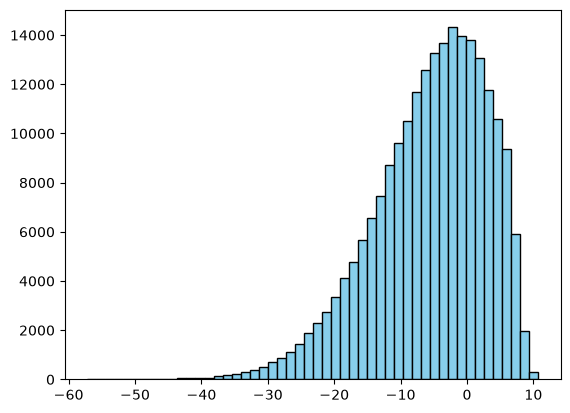

In [ ]:
probas = all_probs[:, 1]
logts = all_logits[:, 1]
log_probs = np.log(probas + 1e-8)
log_odds = all_logits[:, 1] - all_logits[:, 0]

target_data = log_odds
plt.hist(target_data,bins=50, color='skyblue', edgecolor='black')
plt.show()

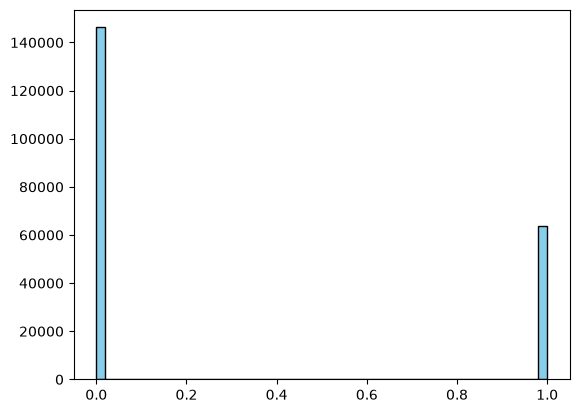

In [31]:
normalized_score = (log_odds - min(log_odds) / (max(log_odds) - min(log_odds)))
normalized_score = np.clip(normalized_score, 0.0, 1.0)

plt.hist(normalized_score, bins=50, color='skyblue', edgecolor='black')
plt.show()

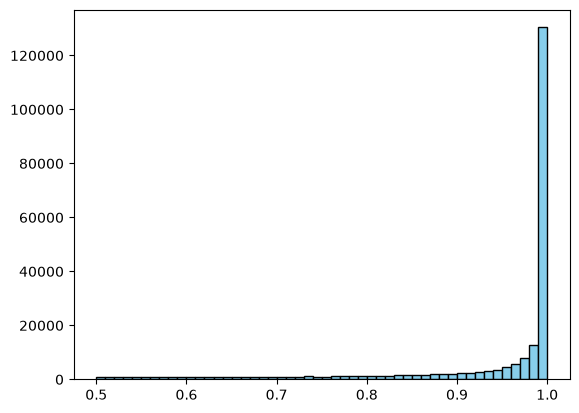

In [34]:
diff_logit = np.abs(all_logits[:,1] - all_logits[:, 0])
cf_sc = F.sigmoid(torch.tensor(diff_logit)).numpy()

plt.hist(cf_sc, color='skyblue', edgecolor='black', bins=50)
plt.show()